## Importing Libraries



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Data



In [5]:
# Load the dataset
file_path = '/content/consumer_electronics_sales_data.csv'
data = pd.read_csv(file_path)

# Display the first few rows
data.head()

,ProductID,ProductCategory,ProductBrand,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
0,5874,Smartphones,Other Brands,312.949668,18,0,2,1,0
1,5875,Smart Watches,Samsung,980.389404,35,1,7,2,1
2,5876,Tablets,Samsung,2606.718293,63,0,1,5,1
3,5877,Smartphones,Samsung,870.395450,63,1,10,3,1
4,5878,Tablets,Sony,1798.955875,57,0,17,3,0


## Data Overview



In [6]:
# Display summary statistics
data.describe()

,ProductID,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,10373.500000,1527.429195,43.347000,0.508889,10.054667,2.996000,0.566444
std,2598.220545,829.900898,15.055084,0.499949,5.461328,1.405301,0.495593
min,5874.000000,100.376358,18.000000,0.000000,1.000000,1.000000,0.000000
25%,8123.750000,809.165014,30.000000,0.000000,5.000000,2.000000,0.000000
50%,10373.500000,1513.024577,43.000000,1.000000,10.000000,3.000000,1.000000
75%,12623.250000,2244.415520,56.000000,1.000000,15.000000,4.000000,1.000000
max,14873.000000,2999.852253,69.000000,1.000000,19.000000,5.000000,1.000000


## Data Cleaning



In [7]:
# Check for missing values
data.isnull().sum()

,0
ProductID,0
ProductCategory,0
ProductBrand,0
ProductPrice,0
CustomerAge,0
CustomerGender,0
PurchaseFrequency,0
CustomerSatisfaction,0
PurchaseIntent,0


## Exploratory Data Analysis (EDA)



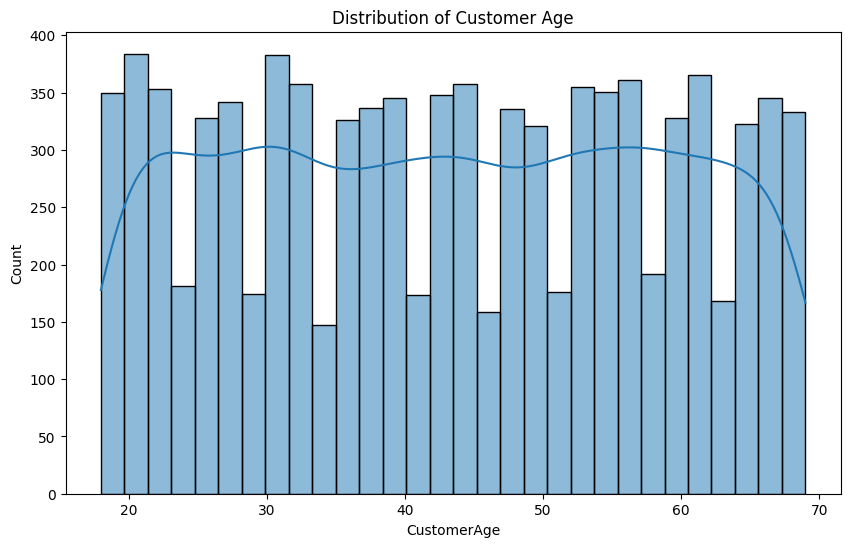

In [ ]:
# Distribution of Customer Age
plt.figure(figsize=(10, 6))
sns.histplot(data['CustomerAge'], bins=30, kde=True)
plt.title('Distribution of Customer Age')
plt.show()

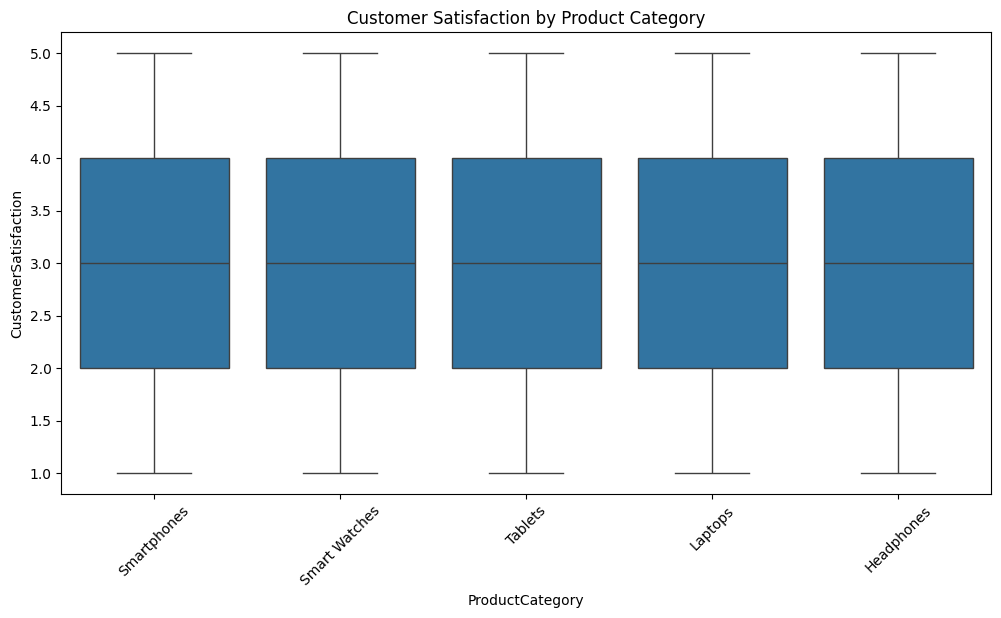

In [ ]:
# Customer Satisfaction by Product Category
plt.figure(figsize=(12, 6))
sns.boxplot(x='ProductCategory', y='CustomerSatisfaction', data=data)
plt.title('Customer Satisfaction by Product Category')
plt.xticks(rotation=45)
plt.show()

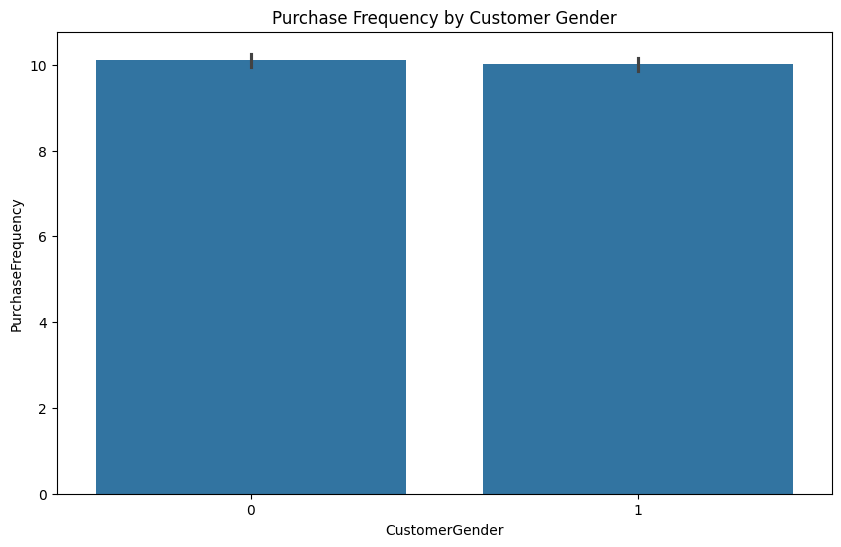

In [ ]:
# Purchase Frequency by Customer Gender
plt.figure(figsize=(10, 6))
sns.barplot(x='CustomerGender', y='PurchaseFrequency', data=data)
plt.title('Purchase Frequency by Customer Gender')
plt.show()

## Further Exploratory Data Analysis

### Univariate Analysis

Let's examine the distributions of individual categorical variables.

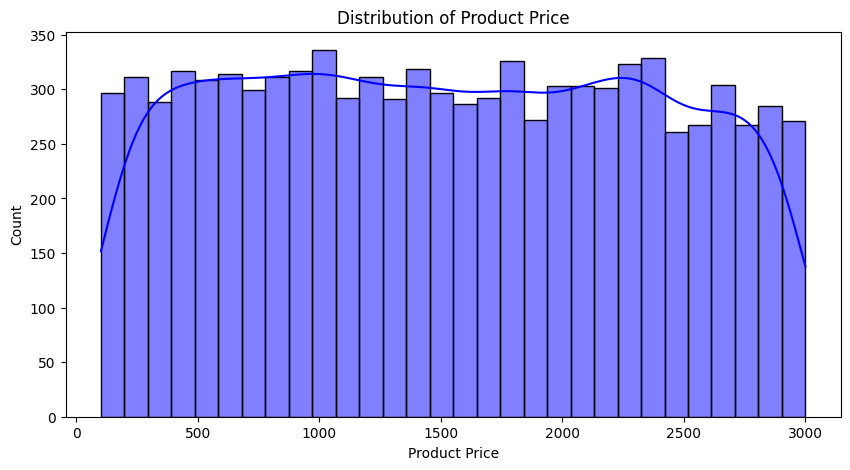

In [9]:
# 1. Univariate distribution of ProductPrice
plt.figure(figsize=(10, 5))
sns.histplot(data['ProductPrice'], bins=30, kde=True, color='blue')
plt.title('Distribution of Product Price')
plt.xlabel('Product Price')
plt.ylabel('Count')
plt.show()



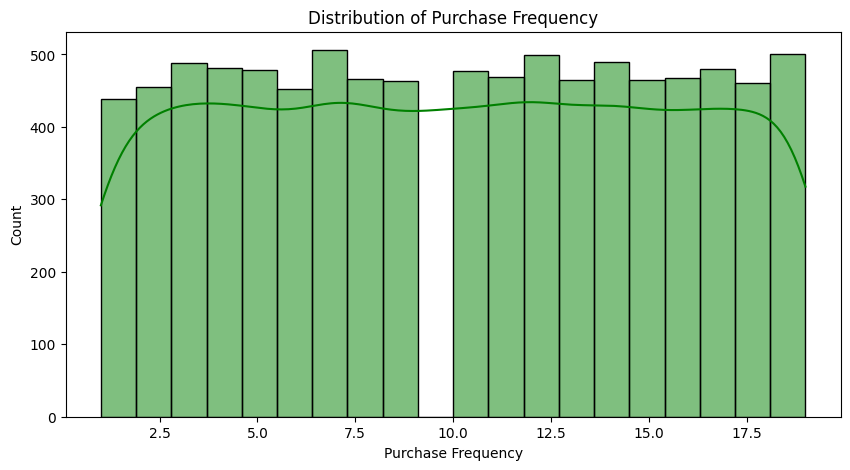

In [10]:
# 2. Univariate distribution of PurchaseFrequency
plt.figure(figsize=(10, 5))
sns.histplot(data['PurchaseFrequency'], bins=20, kde=True, color='green')
plt.title('Distribution of Purchase Frequency')
plt.xlabel('Purchase Frequency')
plt.ylabel('Count')
plt.show()

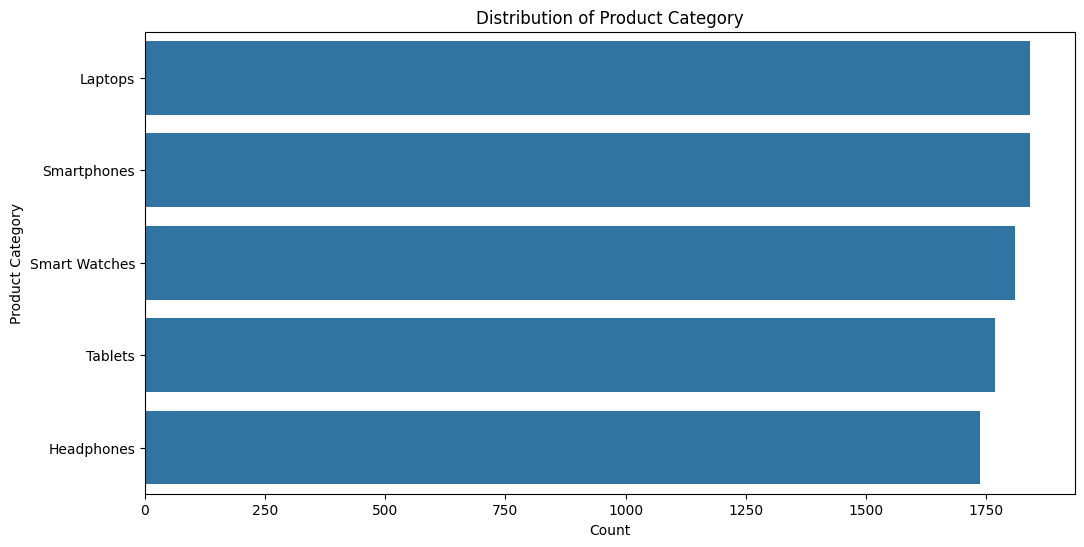

In [ ]:
# Distribution of ProductCategory
plt.figure(figsize=(12, 6))
sns.countplot(y='ProductCategory', data=data, order=data['ProductCategory'].value_counts().index)
plt.title('Distribution of Product Category')
plt.xlabel('Count')
plt.ylabel('Product Category')
plt.show()

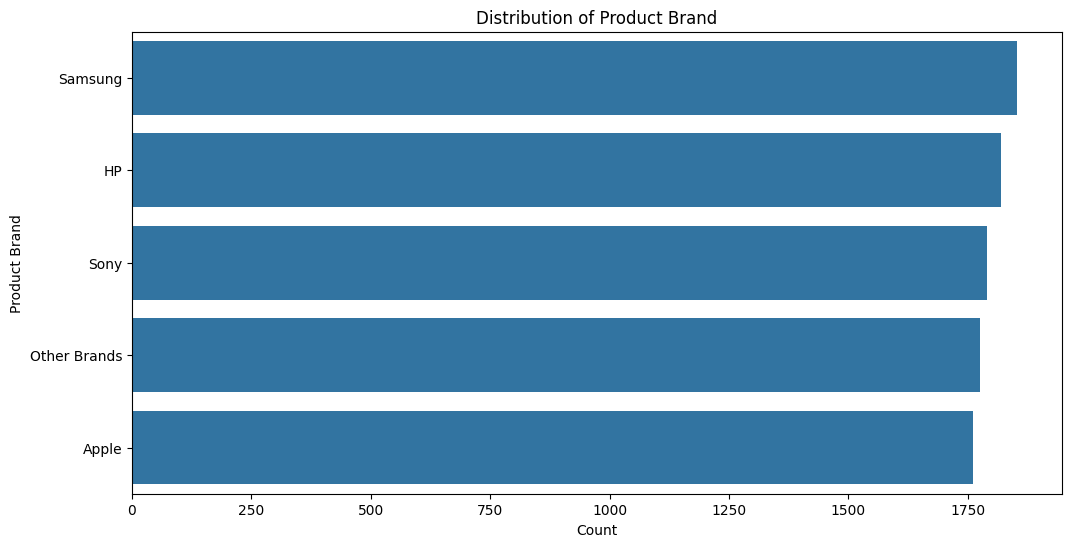

In [ ]:
# Distribution of ProductBrand
plt.figure(figsize=(12, 6))
sns.countplot(y='ProductBrand', data=data, order=data['ProductBrand'].value_counts().index)
plt.title('Distribution of Product Brand')
plt.xlabel('Count')
plt.ylabel('Product Brand')
plt.show()

### Bivariate Analysis

Now, let's explore the relationships between pairs of variables.

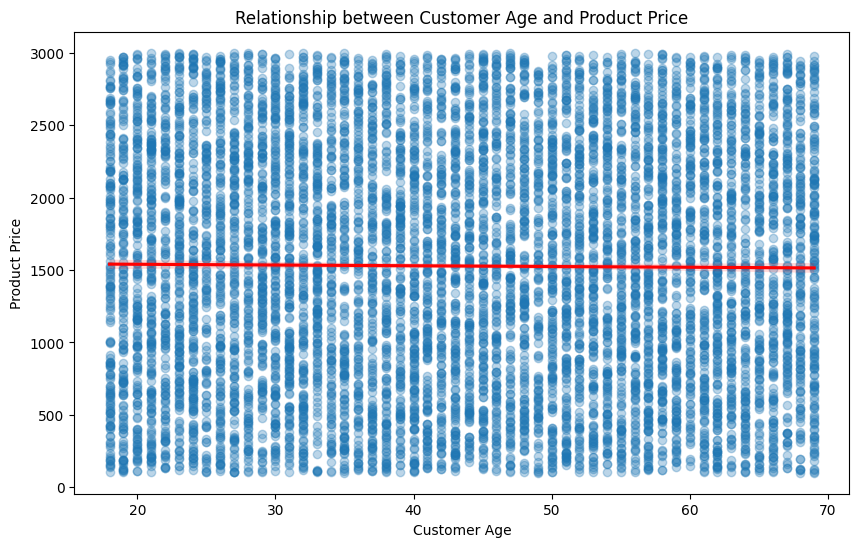

In [12]:

# Bivariate plot: Customer Age vs. Product Price
plt.figure(figsize=(10, 6))
sns.regplot(x='CustomerAge', y='ProductPrice', data=data, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Customer Age and Product Price')
plt.xlabel('Customer Age')
plt.ylabel('Product Price')
plt.show()

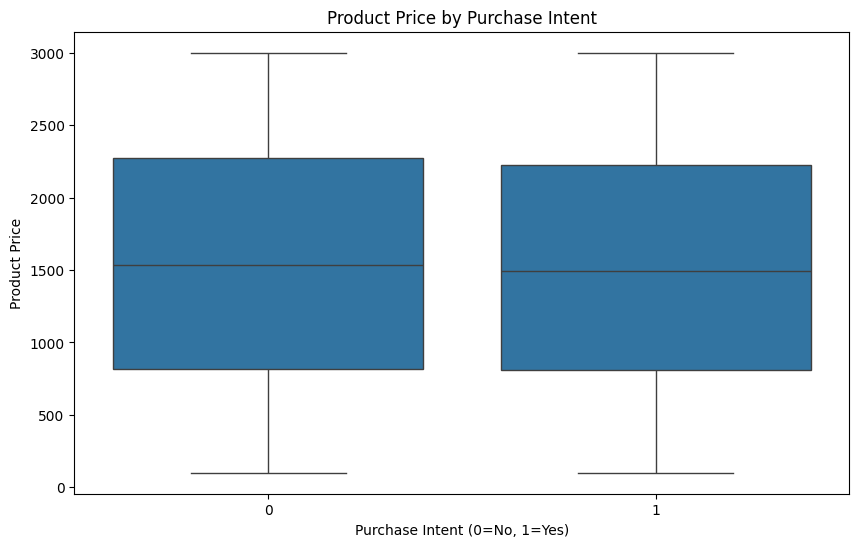

In [ ]:
# ProductPrice vs. PurchaseIntent
plt.figure(figsize=(10, 6))
sns.boxplot(x='PurchaseIntent', y='ProductPrice', data=data)
plt.title('Product Price by Purchase Intent')
plt.xlabel('Purchase Intent (0=No, 1=Yes)')
plt.ylabel('Product Price')
plt.show()

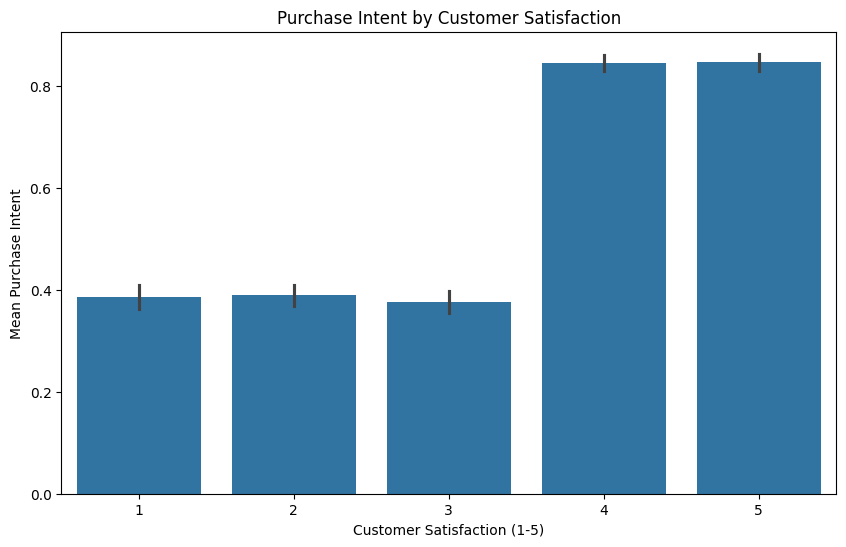

In [ ]:
# CustomerSatisfaction vs. PurchaseIntent
plt.figure(figsize=(10, 6))
sns.barplot(x='CustomerSatisfaction', y='PurchaseIntent', data=data)
plt.title('Purchase Intent by Customer Satisfaction')
plt.xlabel('Customer Satisfaction (1-5)')
plt.ylabel('Mean Purchase Intent')
plt.show()

### Multivariate Analysis

Let's look at relationships involving three or more variables.

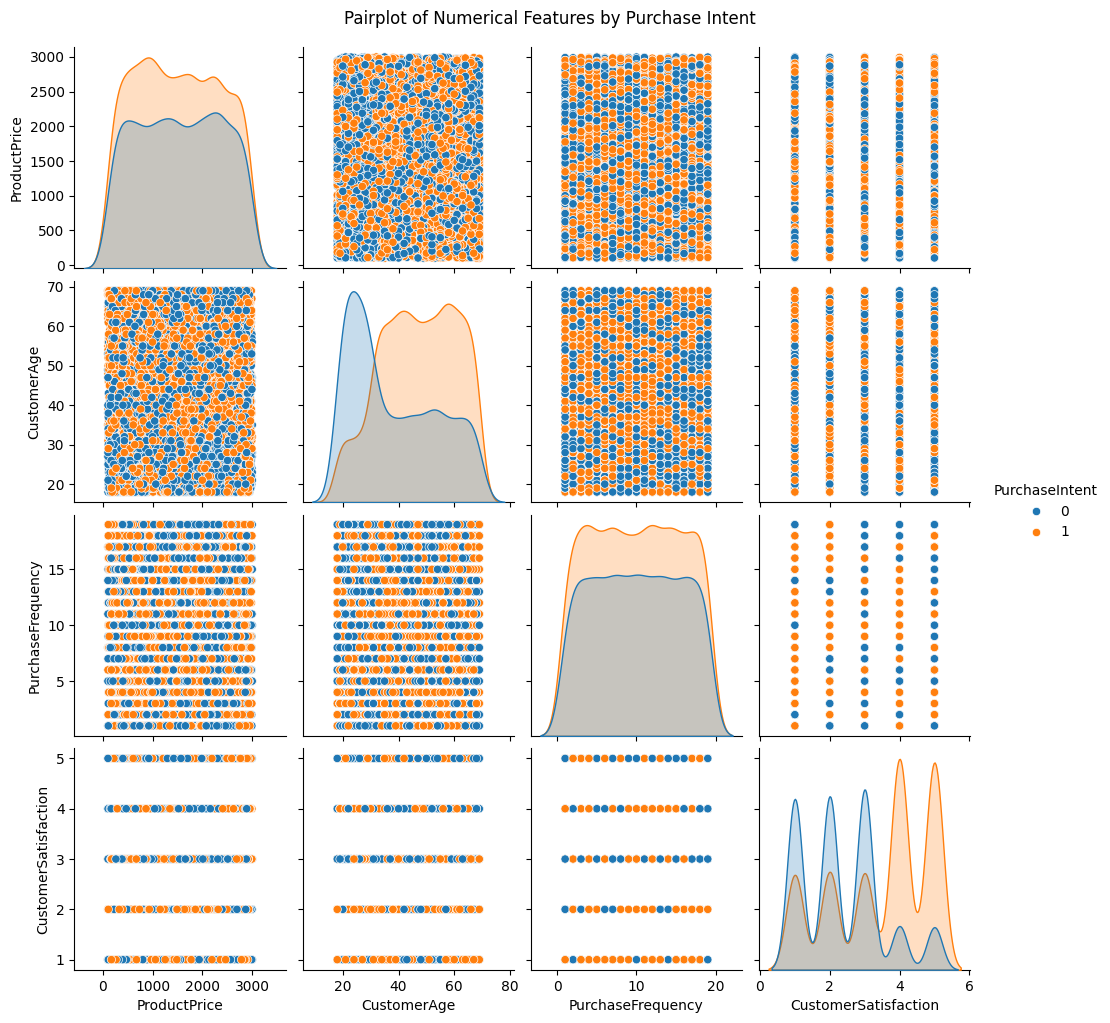

In [ ]:
# Pairplot for selected numerical features, colored by PurchaseIntent
sns.pairplot(data[['ProductPrice', 'CustomerAge', 'PurchaseFrequency', 'CustomerSatisfaction', 'PurchaseIntent']], hue='PurchaseIntent', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by Purchase Intent', y=1.02) # Adjust suptitle position
plt.show()

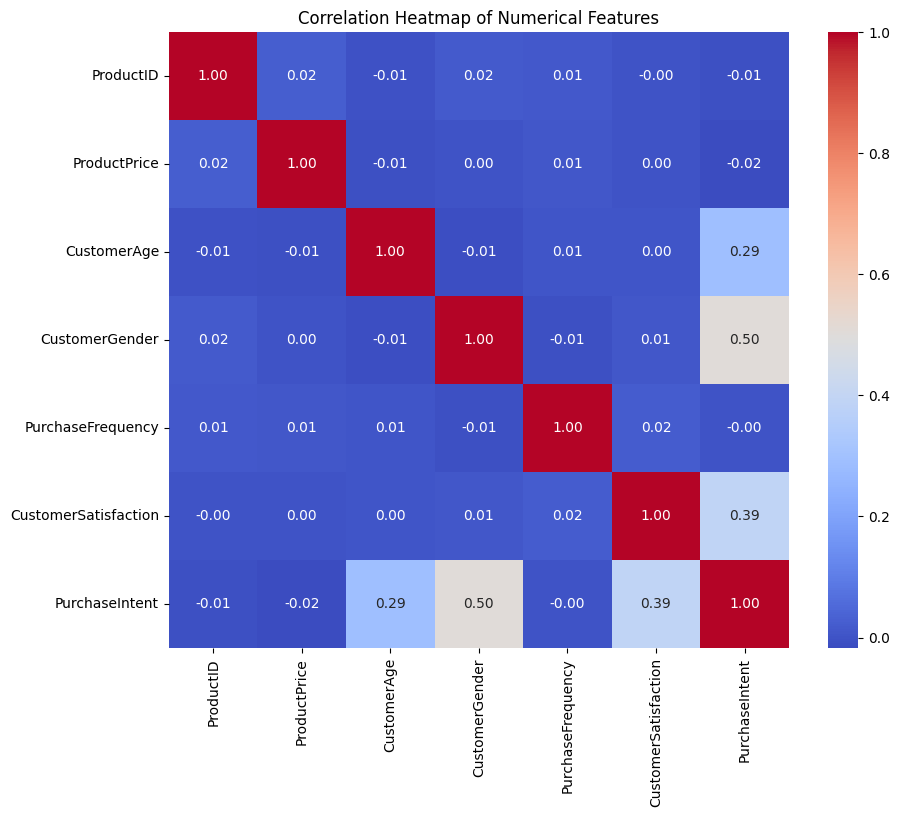

In [ ]:
# Correlation Heatmap of Numerical Features
plt.figure(figsize=(10, 8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

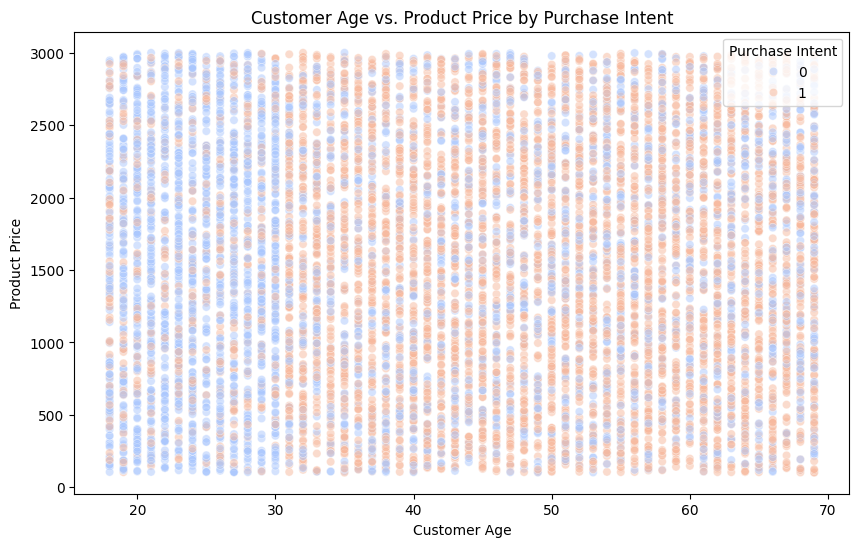

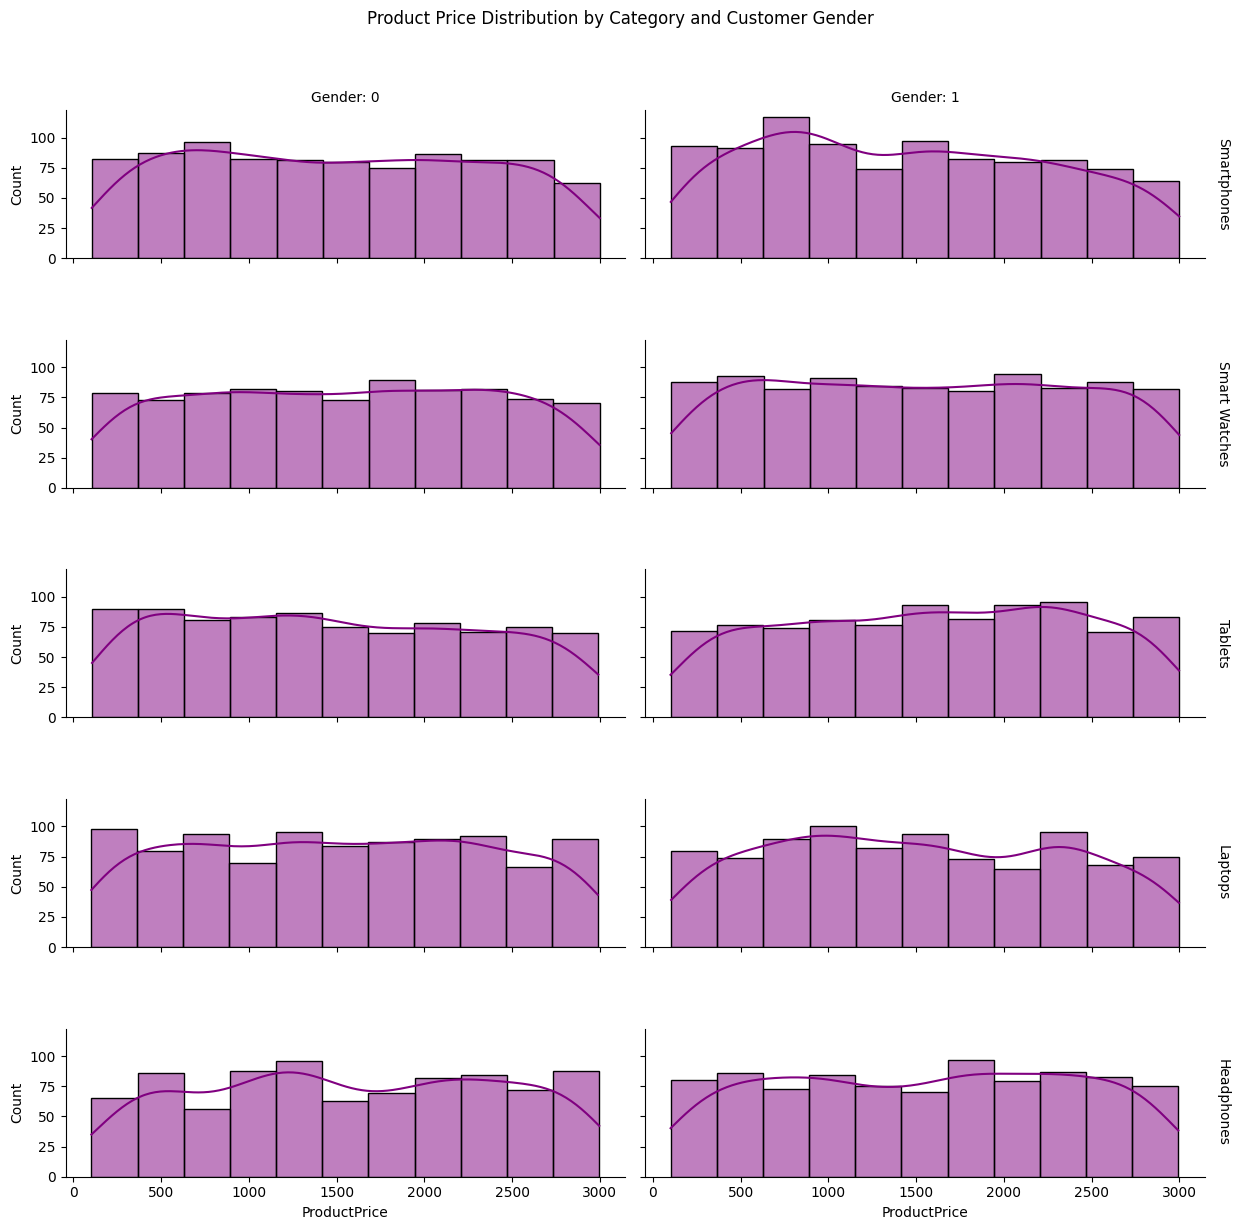

In [13]:


# --- Multivariate Plot 1: Age vs Price colored by Purchase Intent ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CustomerAge', y='ProductPrice', hue='PurchaseIntent', alpha=0.5, data=data, palette='coolwarm')
plt.title('Customer Age vs. Product Price by Purchase Intent')
plt.xlabel('Customer Age')
plt.ylabel('Product Price')
plt.legend(title='Purchase Intent')
plt.show()

# --- Multivariate Plot 2: Product Price Distribution by Category faceted by Gender ---
g = sns.FacetGrid(data, col='CustomerGender', row='ProductCategory', height=2.5, aspect=2.5, margin_titles=True)
g.map(sns.histplot, 'ProductPrice', color='purple', kde=True)
g.set_titles(col_template='Gender: {col_name}', row_template='{row_name}')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Product Price Distribution by Category and Customer Gender')
plt.show()

/tmp/ipykernel_608/978975666.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CustomerSatisfaction', data=data, palette='Blues_r')


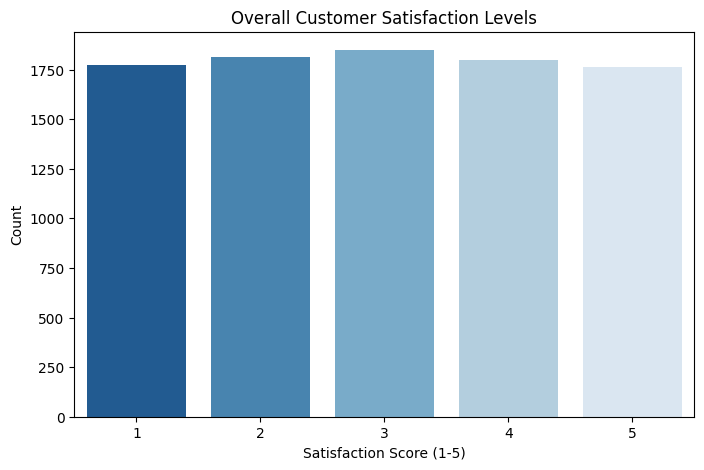

/tmp/ipykernel_608/978975666.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ProductBrand', y='PurchaseIntent', data=data, palette='muted', errorbar=None)


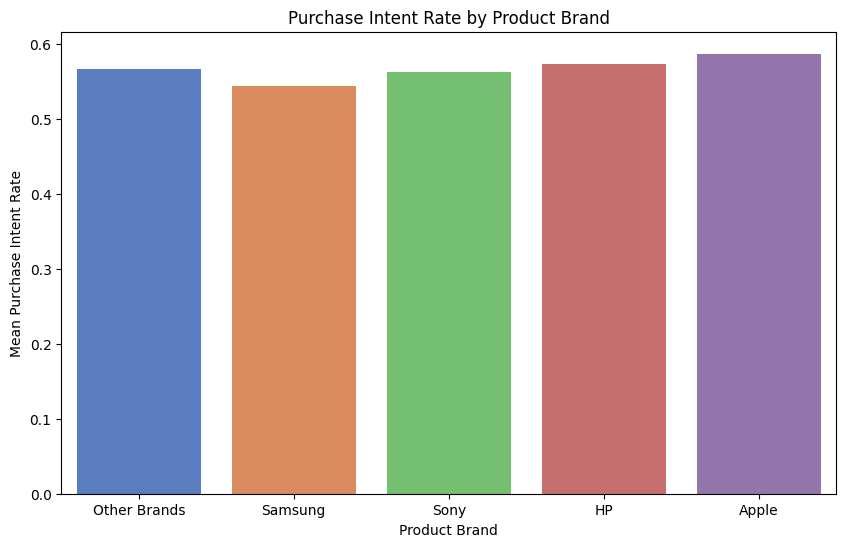

In [14]:

# --- Useful Plot 1: Distribution of Customer Satisfaction ---
plt.figure(figsize=(8, 5))
sns.countplot(x='CustomerSatisfaction', data=data, palette='Blues_r')
plt.title('Overall Customer Satisfaction Levels')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Count')
plt.show()

# --- Useful Plot 2: Purchase Intent rate across Product Brands ---
plt.figure(figsize=(10, 6))
sns.barplot(x='ProductBrand', y='PurchaseIntent', data=data, palette='muted', errorbar=None)
plt.title('Purchase Intent Rate by Product Brand')
plt.xlabel('Product Brand')
plt.ylabel('Mean Purchase Intent Rate')
plt.show()